# 🔵 Class 10.3 — K-Means Clustering
### ML Techniques

**Learning Goals:** Understand K-Means algorithm, implement on Mall Customers, name clusters in plain English.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Ready')

✅ Ready


---
## The K-Means Algorithm

K-Means:
1. Randomly place k centroids
2. Assign each point to nearest centroid
3. Recompute centroids as cluster means
4. Repeat until centroids stop moving

Key parameter: `init='k-means++'` (smart initialisation — avoids poor random starts)

In [2]:
from sklearn.cluster import KMeans

# Create synthetic similar data
np.random.seed(42)
mall = pd.DataFrame({
    'CustomerID': range(1, 201),
    'Gender': np.random.choice(['Male','Female'], 200),
    'Age': np.random.randint(18, 70, 200),
    'Annual Income (k$)': np.random.randint(15, 140, 200),
    'Spending Score (1-100)': np.random.randint(1, 100, 200)
})

print(f'Mall Customers: {mall.shape}')
print(mall.head())
print()
print('Column types:')
print(mall.dtypes)

Mall Customers: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      86
1           2  Female   56                  22                      57
2           3    Male   66                  41                      29
3           4    Male   69                  41                      78
4           5    Male   49                 112                      92

Column types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [3]:
# Use 2 features for visualisation: Annual Income vs Spending Score
X_mall = mall[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Train K-Means with k=5
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_mall)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

print(f'Inertia (within-cluster sum of squares): {kmeans.inertia_:.1f}')
print(f'Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True)))}')


Inertia (within-cluster sum of squares): 76597.5
Cluster sizes: {np.int32(0): np.int64(26), np.int32(1): np.int64(50), np.int32(2): np.int64(33), np.int32(3): np.int64(50), np.int32(4): np.int64(41)}


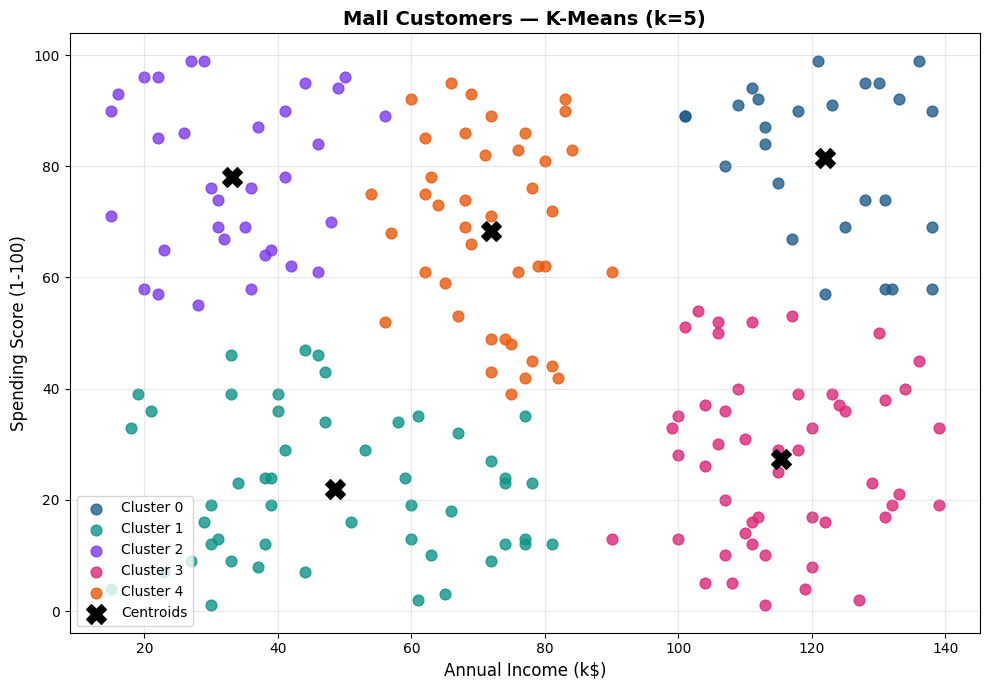

CLUSTER NAMING EXERCISE:
For each cluster, look at the centroid (center) coordinates.
Income axis: low=<40k, medium=40-80k, high=>80k
Spending axis: low=<30, medium=30-70, high=>70

Cluster 0: Income=122k (high), Spending=81 (high)
  Name: VIP target customers — high income, high spend
Cluster 1: Income=49k (medium), Spending=22 (low)
  Name: Average savers
Cluster 2: Income=33k (low), Spending=78 (high)
  Name: Young high-spenders (likely on credit)
Cluster 3: Income=115k (high), Spending=27 (low)
  Name: High-income low-spenders — potential savers / target for premium offers
Cluster 4: Income=72k (medium), Spending=68 (medium)
  Name: Standard middle-class shoppers


In [4]:
# Visualise clusters
colors = ['#1F5C8B','#0D9488','#7C3AED','#DB2777','#EA580C']
plt.figure(figsize=(10, 7))
for i in range(5):
    mask = labels == i
    plt.scatter(X_mall[mask, 0], X_mall[mask, 1],
                c=colors[i], s=60, alpha=0.8, label=f'Cluster {i}')
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200,
            zorder=5, label='Centroids')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Mall Customers — K-Means (k=5)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Name each cluster in plain English
print('CLUSTER NAMING EXERCISE:')
print('For each cluster, look at the centroid (center) coordinates.')
print('Income axis: low=<40k, medium=40-80k, high=>80k')
print('Spending axis: low=<30, medium=30-70, high=>70')
print()

cluster_names = {
    ('low',    'low')   : 'Careful budget shoppers',
    ('low',    'medium'): 'Average lower-income customers',
    ('low',    'high')  : 'Young high-spenders (likely on credit)',
    ('medium', 'low')   : 'Average savers',
    ('medium', 'medium'): 'Standard middle-class shoppers',
    ('medium', 'high')  : 'Mid-income enthusiastic spenders',
    ('high',   'low')   : 'High-income low-spenders — potential savers / target for premium offers',
    ('high',   'medium'): 'Wealthy moderate spenders',
    ('high',   'high')  : 'VIP target customers — high income, high spend',
}

for i in range(5):
    cx, cy = centers[i]
    income_label = 'low' if cx < 40 else ('high' if cx > 80 else 'medium')
    spend_label  = 'low' if cy < 30 else ('high' if cy > 70 else 'medium')
    name = cluster_names.get((income_label, spend_label), 'Mixed segment')
    print(f'Cluster {i}: Income={cx:.0f}k ({income_label}), Spending={cy:.0f} ({spend_label})')
    print(f'  Name: {name}')


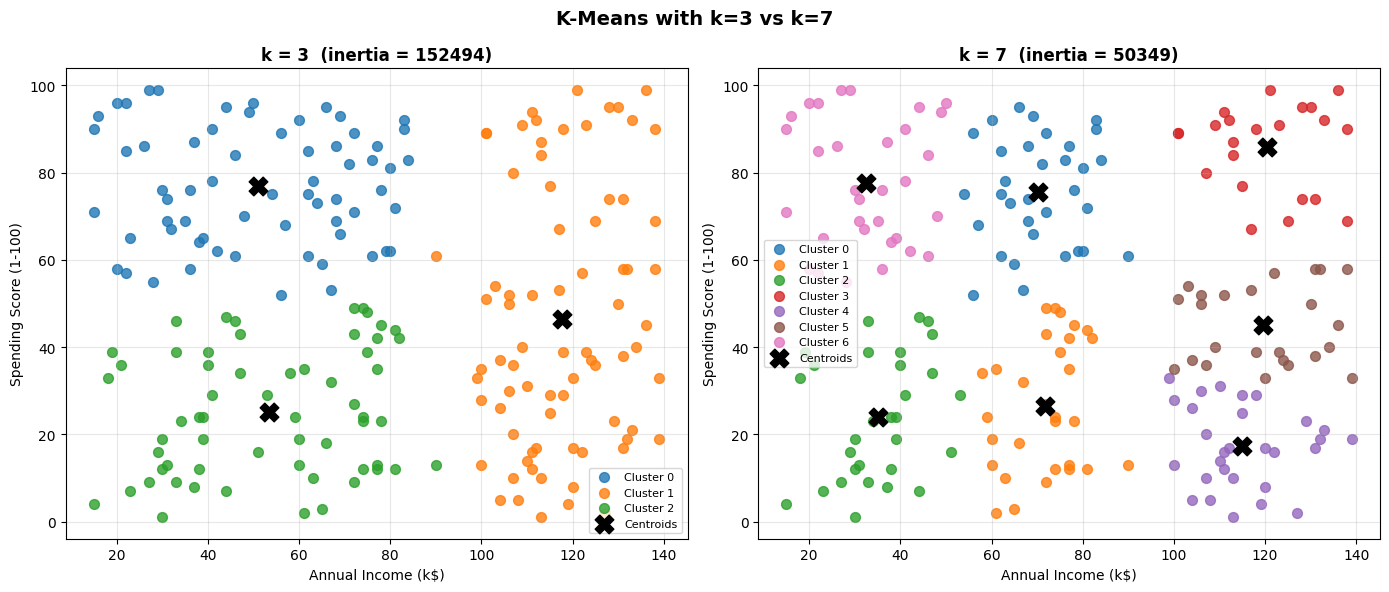

Observation:
  k=3 → clusters are very broad — coarse customer segments, easier to act on but less specific.
  k=7 → clusters get small and overlap — too granular for actionable marketing.
  k=5 (the original choice) is a reasonable middle ground.


In [5]:
### Try k=3 and k=7. How do the clusters change? Which makes more business sense?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, k in zip(axes, [3, 7]):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X_mall)
    palette = plt.cm.tab10.colors
    for i in range(k):
        mask = km.labels_ == i
        ax.scatter(X_mall[mask, 0], X_mall[mask, 1],
                   c=[palette[i % 10]], s=50, alpha=0.8, label=f'Cluster {i}')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='black', marker='X', s=180, zorder=5, label='Centroids')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.set_title(f'k = {k}  (inertia = {km.inertia_:.0f})', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('K-Means with k=3 vs k=7', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Observation:')
print('  k=3 → clusters are very broad — coarse customer segments, easier to act on but less specific.')
print('  k=7 → clusters get small and overlap — too granular for actionable marketing.')
print('  k=5 (the original choice) is a reasonable middle ground.')


---
## ✅ Complete!

- K-Means requires k specified in advance
- `k-means++` initialisation avoids poor random starts
- `inertia_` = total within-cluster variation (lower = better fit)
- **Unsupervised**: no labels — clusters are found, not predicted